# 10 — Support Vector Machines and Kernel Methods
**Goal:** Understand the maximum-margin classifier, the kernel trick, and
why SVMs gave the field its modern shape. Source: ISLR Ch9, Bishop Ch7,
Schölkopf & Smola (2002) *Learning with Kernels*.

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/learning_courses')

import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC, SVR
from sklearn.datasets import make_circles, make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
np.random.seed(10)

## 1. The maximum margin classifier

Among all hyperplanes that separate the two classes, pick the one that
leaves the **largest margin** — the largest perpendicular distance to the
nearest training point. Those nearest points are the **support vectors**.

    min_{w,b,‖w‖=1}  margin = min_i yᵢ(w⊤xᵢ + b)
    subject to        yᵢ(w⊤xᵢ + b) ≥ margin,  ∀ i

Equivalently (rescaling), minimize ‖w‖ subject to yᵢ(w⊤xᵢ + b) ≥ 1.

Geometrically: low-bias (just a hyperplane), low-variance (only the support
vectors matter), and unique (a strictly convex problem).

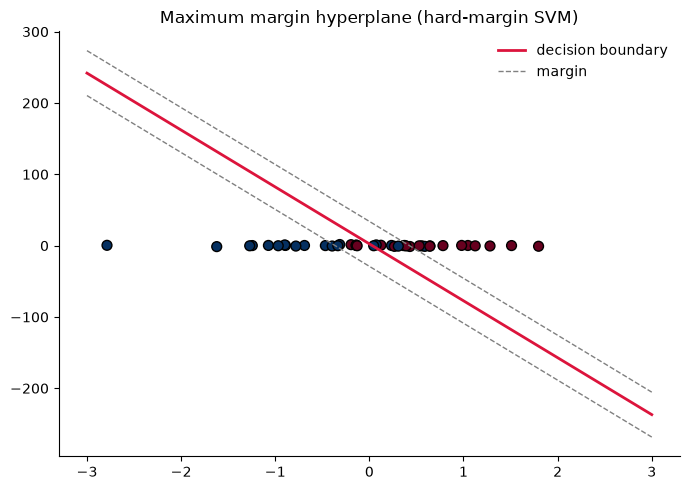

In [2]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=40, centers=[[-1, 0], [1, 0]], cluster_std=0.7, random_state=0)
clf = make_pipeline(StandardScaler(), SVC(kernel='linear', C=1e6)).fit(X, y)
w = clf[-1].coef_[0]; b = clf[-1].intercept_[0]
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(*X.T, c=y, cmap='RdBu_r', s=50, edgecolor='k')
xs = np.linspace(-3, 3, 100)
ax.plot(xs, -(w[0]*xs + b)/w[1], color='crimson', lw=2, label='decision boundary')
ax.plot(xs, -(w[0]*xs + b - 1)/w[1], color='gray',   lw=1, linestyle='--', label='margin')
ax.plot(xs, -(w[0]*xs + b + 1)/w[1], color='gray',   lw=1, linestyle='--')
ax.legend(frameon=False); ax.spines[['top','right']].set_visible(False)
ax.set_title('Maximum margin hyperplane (hard-margin SVM)')
plt.tight_layout(); plt.show()

## 2. The soft margin — the slack variable

Real data is not linearly separable. Introduce slack variables ξᵢ ≥ 0:

    yᵢ(w⊤xᵢ + b) ≥ 1 - ξᵢ
    min  ½‖w‖² + C Σᵢ ξᵢ

C > 0 controls the trade-off between margin width and violations. C → ∞
recovers the hard margin; C → 0 ignores the data.

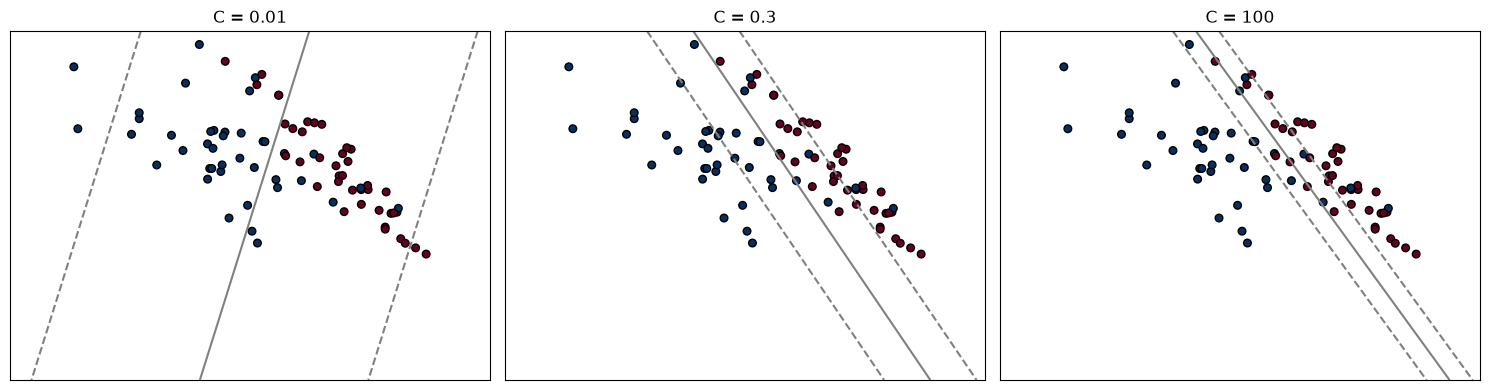

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
X, y = make_classification(n_samples=80, n_features=2, n_redundant=0, n_clusters_per_class=1, random_state=0)
X[:, 0] += (y == 0) * 0.5  # add some overlap
for ax, C in zip(axes, [0.01, 0.3, 100]):
    clf = make_pipeline(StandardScaler(), SVC(kernel='linear', C=C)).fit(X, y)
    xs = np.linspace(X[:, 0].min()-1, X[:, 0].max()+1, 200)
    xx, yy = np.meshgrid(xs, xs)
    zz = clf.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contour(xx, yy, zz, levels=[-1, 0, 1], colors='gray', linestyles=['--','-','--'])
    ax.scatter(*X.T, c=y, cmap='RdBu_r', s=30, edgecolor='k')
    ax.set_title(f'C = {C}')
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 3. The dual problem — where the kernel trick lives

The primal SVM is a convex quadratic program in d + n variables. The dual is
a QP in n variables αᵢ, with the property that the solution depends on x
**only through inner products** xᵢ⊤xⱼ.

    max_α  Σᵢ αᵢ - ½ Σᵢⱼ αᵢ αⱼ yᵢ yⱼ xᵢ⊤xⱼ
    subject to  0 ≤ αᵢ ≤ C,  Σ αᵢ yᵢ = 0

    w = Σᵢ αᵢ yᵢ xᵢ
    f(x) = Σᵢ αᵢ yᵢ xᵢ⊤x + b

Support vectors are the points with αᵢ > 0 — only they influence the
boundary.

## 4. The kernel trick

**Idea:** replace every inner product xᵢ⊤xⱼ with a kernel k(xᵢ, xⱼ) that
corresponds to an inner product in some (possibly infinite-dimensional)
feature space.

Three common kernels:

| Kernel | k(x, x') | Implicit feature map |
|---|---|---|
| Linear | x⊤x' | identity |
| Polynomial (deg d) | (γ x⊤x' + r)ᵈ | monomials up to degree d |
| RBF (Gaussian) | exp(-γ‖x - x'‖²) | infinite-dim; all radial basis functions |
| Sigmoid | tanh(γ x⊤x' + r) | not a valid kernel everywhere, but in practice |

With RBF kernel the SVM is an **infinite-dimensional linear classifier** in
feature space — yet the dual still has only n variables.

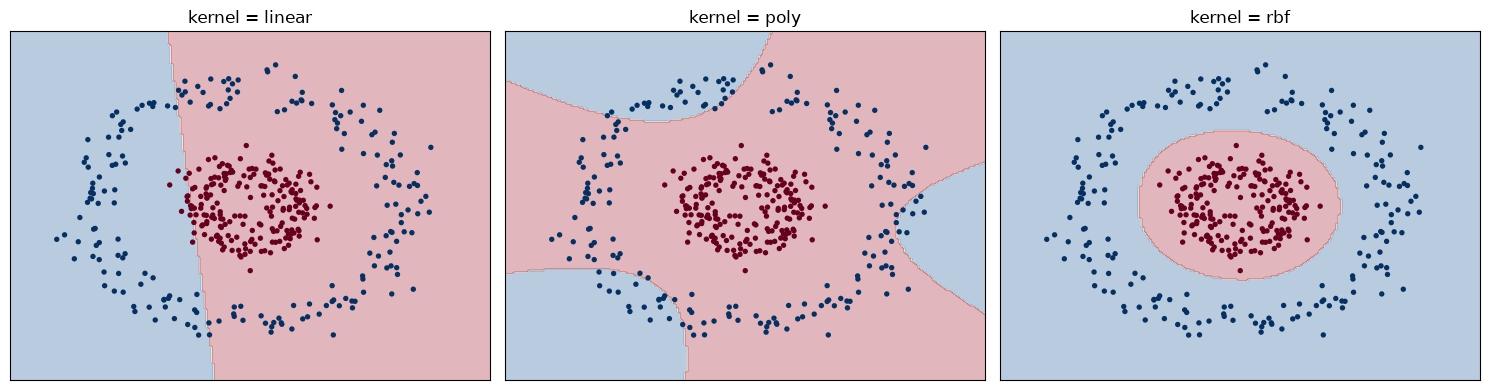

In [4]:
X, y = make_circles(n_samples=400, factor=0.3, noise=0.1, random_state=0)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, k in zip(axes, ['linear', 'poly', 'rbf']):
    clf = make_pipeline(StandardScaler(), SVC(kernel=k, gamma='auto')).fit(X, y)
    xs = np.linspace(-1.5, 1.5, 200); xx, yy = np.meshgrid(xs, xs)
    zz = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, zz, alpha=0.3, cmap='RdBu_r')
    ax.scatter(*X.T, c=y, cmap='RdBu_r', s=15, edgecolor='none')
    ax.set_title(f'kernel = {k}')
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 5. RBF and the bandwidth γ

    k(x, x') = exp(-γ ‖x - x'‖²)

γ controls the locality:
- Small γ → wide kernel → smoother decision boundary → high bias.
- Large γ → narrow kernel → wiggly boundary → high variance.

Tune (C, γ) jointly by cross-validation. A common rule of thumb is to start
with `C=1, gamma='scale'` (which is `1 / (d · Var(X))`) and grid-search.

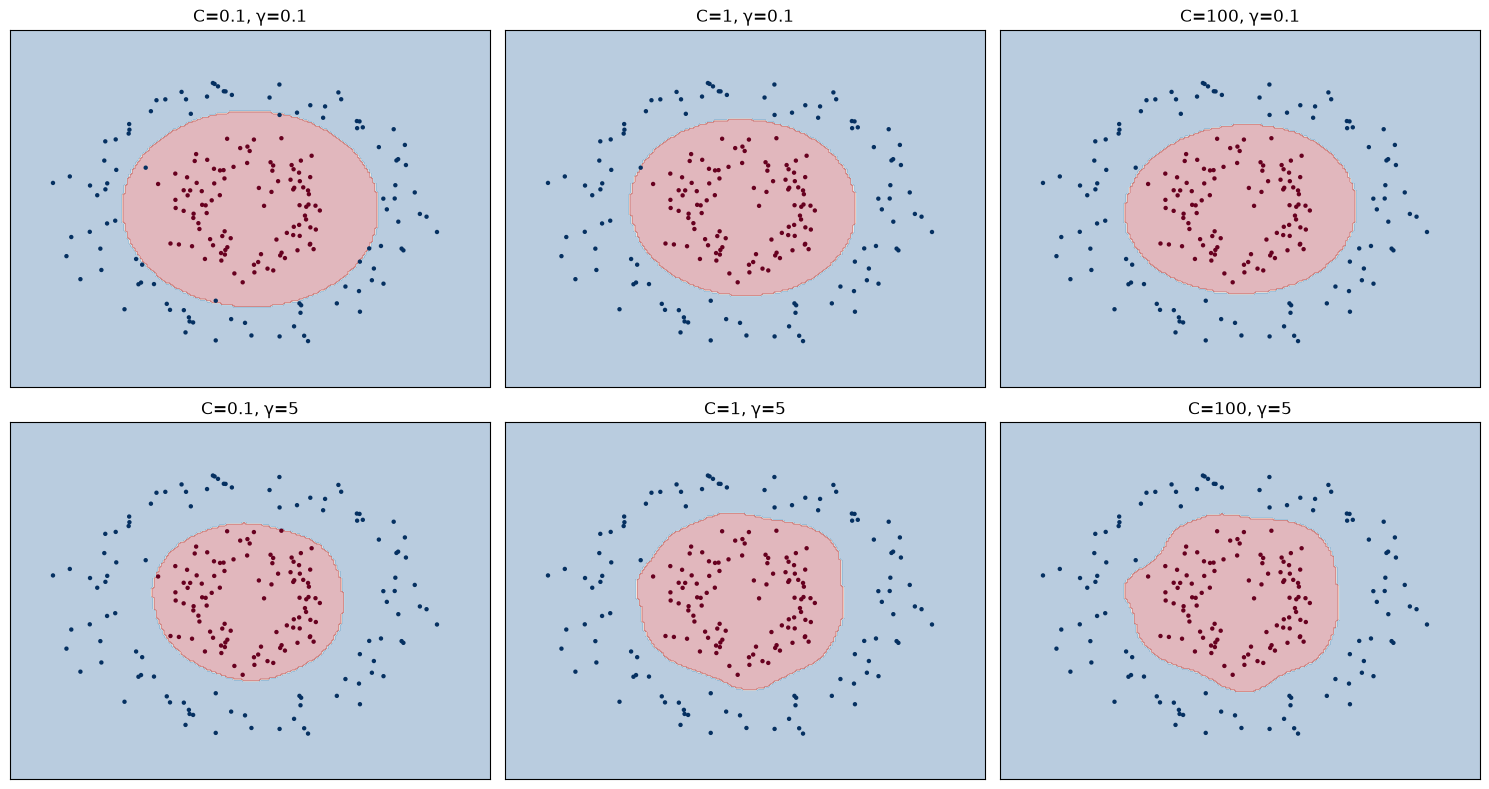

In [5]:
X, y = make_circles(n_samples=200, factor=0.4, noise=0.1, random_state=0)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (C, gamma) in zip(axes.ravel(),
    [(0.1, 0.1), (1, 0.1), (100, 0.1), (0.1, 5), (1, 5), (100, 5)]):
    clf = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=C, gamma=gamma)).fit(X, y)
    xs = np.linspace(-1.5, 1.5, 200); xx, yy = np.meshgrid(xs, xs)
    zz = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, zz, alpha=0.3, cmap='RdBu_r')
    ax.scatter(*X.T, c=y, cmap='RdBu_r', s=10, edgecolor='none')
    ax.set_title(f'C={C}, γ={gamma}')
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 6. SVM regression (SVR)

Same idea, different loss. Use an ε-insensitive tube: errors within ±ε do not
contribute to the loss. The objective is to keep predictions in the tube
while staying as flat as possible.

    min  ½‖w‖² + C Σᵢ (ξᵢ + ξᵢ*)
    subject to  yᵢ - w⊤xᵢ - b ≤ ε + ξᵢ
                w⊤xᵢ + b - yᵢ ≤ ε + ξᵢ*
                ξ, ξ* ≥ 0

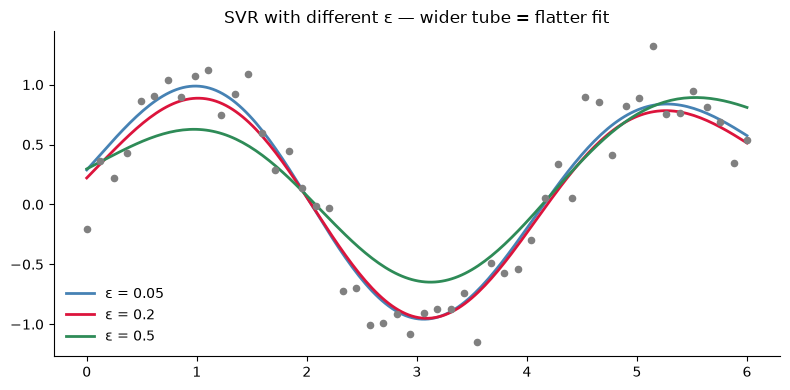

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
X = np.linspace(0, 6, 50).reshape(-1, 1)
y = np.sin(1.5 * X.ravel()) + 0.2 * np.random.randn(50)
for eps, c in zip([0.05, 0.2, 0.5], ['steelblue', 'crimson', 'seagreen']):
    m = SVR(kernel='rbf', C=1, epsilon=eps).fit(X, y)
    xs = np.linspace(0, 6, 200).reshape(-1, 1)
    ax.plot(xs, m.predict(xs), color=c, lw=2, label=f'ε = {eps}')
ax.scatter(X, y, s=20, color='gray', zorder=3)
ax.legend(frameon=False); ax.spines[['top','right']].set_visible(False)
ax.set_title('SVR with different ε — wider tube = flatter fit')
plt.tight_layout(); plt.show()

## 7. SVMs vs logistic regression vs trees

| | SVM | Logistic | Tree |
|---|---|---|---|
| Decision boundary | linear in feature / kernel space | linear | axis-aligned steps |
| Probabilities | need calibration (Platt) | native | native (leaf freq) |
| n_features ≫ n | linear SVM fine | ridge-regularized logreg | trees fine |
| n moderate, complex boundary | RBF SVM excellent | underfits | RF can be better |
| Interpretability | support vectors | coefficients | can be drawn |
| Training time | O(n² - n³) | O(nd) | O(n log n) |

**Practical rule (2024):** SVMs are still strong on small-to-medium tabular
data and on text classification. For everything else start with
gradient-boosted trees or a neural net.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
X, y = make_classification(n_samples=500, n_features=20, n_informative=8, random_state=0)
for name, m in [
    ('LogReg',     make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))),
    ('SVM (RBF)',  make_pipeline(StandardScaler(), SVC(kernel='rbf', C=1, gamma='scale'))),
    ('SVM (lin)',  make_pipeline(StandardScaler(), SVC(kernel='linear', C=1))),
    ('RF',         RandomForestClassifier(n_estimators=200, random_state=0)),
]:
    from sklearn.model_selection import cross_val_score
    s = cross_val_score(m, X, y, cv=5)
    print(f'{name:14s}  acc = {s.mean():.3f} \u00b1 {s.std():.3f}')

LogReg          acc = 0.900 ± 0.024
SVM (RBF)       acc = 0.930 ± 0.030
SVM (lin)       acc = 0.896 ± 0.033


RF              acc = 0.922 ± 0.035


## 8. Beyond SVMs — kernel methods more broadly

SVMs are the most famous kernel method, but the same idea generalizes:

- **Kernel ridge regression** — squared loss + L2 + kernel.
- **Gaussian process regression** — Bayesian kernel regression with
  uncertainty.
- **Kernel PCA / K-means** — non-linear versions of classical methods.
- **Neural tangent kernel (NTK)** — the kernel of an infinitely-wide
  neural network (Jacot et al. 2018) — deep theory that connects kernels
  and deep learning.

**When the n is small and the structure is rich, kernel methods are still
the state of the art. When n is large, deep learning wins.**

## Summary

| Concept | Key point |
|---|---|
| Max margin | among separating hyperplanes, pick the widest one |
| Soft margin (C) | trade-off between margin width and violations |
| Dual | solution depends on x only through inner products |
| Kernel trick | replace inner product with k(x, x') |
| RBF kernel | infinite-dim feature map; tune γ |
| SVR | ε-insensitive tube around the regression line |

**Next:** `11_unsupervised_learning.ipynb` — clustering, PCA, and the
tools for when you have no labels.